# DEMO: Quintom Model in CLASS
This notebook demonstrates how to initialize and run the Quintom model using the `classy` Python wrapper.

In [1]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt

## Initialization
Set parameters: $\Omega_\Lambda = 0$ must be enforced if using Quintom as sole dark energy.

In [14]:
fixed_params = {
    'h': 0.67,
    'Neff': 3.044,
    'N_ncdm': 1,
    'm_ncdm': 0.06,
    'omega_b': 0.02238280,
    'omega_cdm': 0.1201075,
    'output': 'tCl, mPk',
}

In [7]:
quintom_params = {    
    'Omega_Lambda': 0,
    'Omega_fld' : 0,
    'Omega_qtm': -1,
    'coupled_baryon_qtm' : 'yes',
    'coupled_cdm_qtm' : 'yes',
}
lcdm_params = {
    'coupled_baryon_qtm' : 'no',
    'coupled_cdm_qtm' : 'no',
}

### Quintom Model

In [15]:
qtm = Class()
qtm.set(fixed_params)
qtm.set(quintom_params)
qtm.set({'lambda_qtm' : 0.185755, 
         'delta_qtm': -0.00695466,
         })
qtm.compute()

bg_qtm = qtm.get_background()
derived = qtm.get_current_derived_parameters(['100*theta_s'])
qtm.struct_cleanup()
qtm.empty()

### $\Lambda$ CDM Model


In [6]:
# LCDM model
lcdm = Class()
lcdm.set({**fixed_params, **lcdm_params})
lcdm.compute()

bg_lcdm = lcdm.get_background()
lcdm_derived = lcdm.get_current_derived_parameters(['100*theta_s'])
lcdm.struct_cleanup()
lcdm.empty()

## Extracting Derived Parameters

## Background Evolution Plot
We can retrieve background quantities to plot $\Omega_i$.

In [8]:
z = bg_qtm['z']
a = 1/(z+1.0)
rho_tot_qtm = bg_qtm['(.)rho_tot']
rho_tot_lcdm = bg_lcdm['(.)rho_tot']

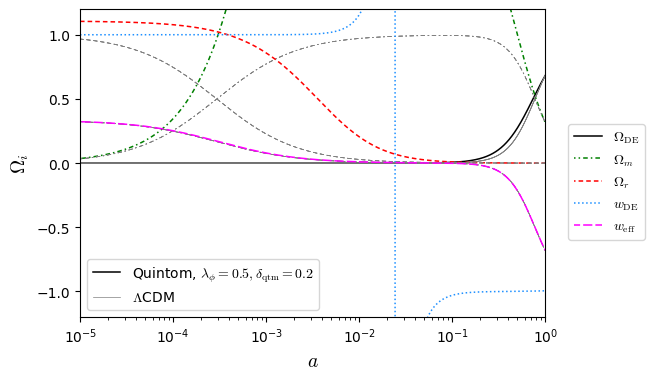

In [11]:
# from matplotlib.lines import lineStyles
plt.rcParams['mathtext.fontset'] = 'cm'

# quintom model
omega_qtm = bg_qtm['(.)rho_qtm'] / rho_tot_qtm
omega_cdm_qtm = bg_qtm['(.)rho_cdm'] / rho_tot_qtm
omega_b_qtm = bg_qtm['(.)rho_b'] / rho_tot_qtm
omega_m_qtm = omega_cdm_qtm + omega_b_qtm
omega_r_qtm = (bg_qtm['(.)rho_g'] + bg_qtm['(.)rho_ur']) / rho_tot_qtm
w_qtm = bg_qtm['(.)p_qtm']/bg_qtm['(.)rho_qtm']
w_eff = bg_qtm['(.)p_tot']/bg_qtm['(.)rho_tot']

# lcdm model
omega_lcdm = bg_lcdm['(.)rho_lambda'] / rho_tot_lcdm
omega_cdm_lcdm = bg_lcdm['(.)rho_cdm'] / rho_tot_lcdm
omega_b_lcdm = bg_lcdm['(.)rho_b'] / rho_tot_lcdm
omega_m_lcdm = omega_cdm_lcdm + omega_b_lcdm
omega_r_lcdm = (bg_lcdm['(.)rho_g'] + bg_lcdm['(.)rho_ur']) / rho_tot_lcdm
w_eff_lcdm = bg_lcdm['(.)p_tot']/bg_lcdm['(.)rho_tot']

lwqtm = 1.1
qty_list = [omega_qtm, omega_m_qtm, omega_r_qtm, w_qtm, w_eff]
lb_list = [r'$\Omega_\text{DE}$', r'$\Omega_{m}$', r'$\Omega_r$', r'$w_\text{DE}$', r'$w_\text{eff}$']
cl_list = ['k', 'green', 'red', 'dodgerblue', 'magenta']
lsty_list = ['-', (2,(3,2,1,2)), (2, (3, 2)), ':', (2, (6, 2))]

lwlcdm=0.5
lcdm_qty_list = [omega_lcdm, omega_m_lcdm, omega_r_lcdm, w_eff_lcdm]
lcdm_cl_list = ['gray', 'gray', 'gray', 'gray']
lcdm_lsty_list = ['-', (4,(6,4,2,4)), (4, (6, 4)), (4, (12, 4))]


fig, ax = plt.subplots(figsize=(6, 4))

qtm_lins = {}
lcdm_lins = {}
for k in range(5):
    qtm_lins[k], = ax.semilogx(a, qty_list[k], color=cl_list[k], linestyle=lsty_list[k], lw=lwqtm)
    
    for i, j in enumerate(lcdm_qty_list):
        if k == 4:
            continue
        lcdm_lins[k],=ax.semilogx(a, lcdm_qty_list[k], color=lcdm_cl_list[k], linestyle=lcdm_lsty_list[k], lw=lwlcdm)

handles=[qtm_lins[0], lcdm_lins[0]]
first_lgd = ax.legend(handles, [r'Quintom, $\lambda_\phi=0.5, \delta_\text{qtm}=0.2$', r'$\Lambda$CDM'])
ax.add_artist(first_lgd)
omegas = [qtm_lins[k] for k in range(5)]
ax.legend(omegas, [lb_list[k] for k in range(5)], loc=(1.05,0.25))

# plt.legend(ncol=2)
plt.xlabel(r'$a$', fontsize=14)
plt.ylabel(r'$\Omega_i$', fontsize=14)
plt.xlim(1e-5, 1)
plt.ylim(-1.2, 1.2)
# plt.title('Evolution of the density parameters', fontsize=16)
# plt.grid(True)
plt.savefig('Omega_evolution_qtm.pdf',bbox_inches='tight')
plt.show()